# AG-HYPOPT · Trial 35

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirty-four trials are registered; cell 2 reports `phase = trials` (34/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074), with trial_30 (0.1083) second. Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- best (all 0 div): trial_21 0.1074 (0.138), trial_30 0.1083 (0.134), trial_22 0.1095 (0.137), trial_32 0.1097 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_31 0.1106 (0.131), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_33 0.1120 (0.143), trial_18 0.1121 (0.138), trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127.
- worse: trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (**0.194**), trial_06 = trial_11 0.1188, trial_02 0.1449 (**0.264**).
- diverging at 1nW T05 (near-optimum travel): trial_29 0.1331, trial_26 0.1368, trial_28 0.1370, trial_34 0.1380. Other diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418.

State of play: the mu-travel axis is a single narrow optimum at ~0.137-0.138 with balanced gamma knobs, rising monotonically on both sides (trial_27 at 0.194 -> 0.1149; trial_02 at 0.264 -> 0.1449; low travel worse too). Seven surviving samples sit below 0.111 (0.1074-0.1106). The schedule search is converged; the sporadic 1nW T05 gamma divergence (now ~1 in 3 at the optimum) is the only significant residual. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_35'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (34/5 trials)
ID |     ei | params
 1 | 3.4598 | {"gamma_anneal": 0.5024019103560926, "lr_gamma": 0.42532214239996224, "lr_mu": 0.005441550682795695, "mu_anneal": 0.3247401611709607}
 2 | 3.2907 | {"gamma_anneal": 0.5233939583604862, "lr_gamma": 0.4374323807631129, "lr_mu": 0.1658251339359766, "mu_anneal": 0.028871525898551353}
 3 | 2.3119 | {"gamma_anneal": 0.533923520196805, "lr_gamma": 0.6946261844171912, "lr_mu": 0.1615256412984502, "mu_anneal": 0.34562792919632707}
 4 | 3.6696 | {"gamma_anneal": 0.45309249674643964, "lr_gamma": 0.38930895432914137, "lr_mu": 0.3513794951192145, "mu_anneal": 0.3456662766121816}
 5 | 0.1256 | {"gamma_anneal": 0.5194474129110126, "lr_gamma": 0.4409159361932464, "lr_mu": 0.11945343256121375, "mu_anneal": 0.2769435296486542}
 6 | 2.5777 | {"gamma_anneal": 0.5355703045430427, "lr_gamma": 0.43864012088243204, "lr_mu": 0.1670886875017427, "mu_anneal": 0.32710638233489214}
 7 | 2.5591 | {"gamma_anneal": 0.44272747337813595, "lr_gamma": 0.465

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (34 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 4: ei 3.67 — `lr_mu=0.3514`, `mu_anneal=0.3457` (travel **0.291**), `lr_gamma=0.3893`, `gamma_anneal=0.4531`.
- candidate 1: ei 3.46 — `lr_mu=0.0054`, `mu_anneal=0.3247` (travel 0.005, near zero), `lr_gamma=0.4253`.
- candidate 8: ei 3.40 — `lr_mu=0.1475`, `mu_anneal=0.3510` (travel **0.122**), `lr_gamma=0.4228`, `gamma_anneal=0.4942`.
- candidate 2: ei 3.29 — `lr_mu=0.1658`, `mu_anneal=0.0289` (travel 0.163), `lr_gamma=0.4374`.
- candidate 7: ei 2.56 — `lr_mu=0.1584`, `mu_anneal=0.3454` (travel 0.131), `lr_gamma=0.4653`.

The maximum-ei candidate (4) is at travel 0.291 - a near-extreme, well beyond trial_02's 0.264 which already gave 0.1449. The evidence on the mu axis is unambiguous and monotone: the objective rises on both sides of a narrow optimum at ~0.137, so a trial at 0.291 would almost certainly score ~0.14+ and teach nothing new. Candidate 1 (travel 0.005) is the opposite extreme, equally uninformative. The highest-ei candidate *inside* the productive band is candidate 8 (ei 3.40, travel 0.122), which sits at the lower edge of the optimum band (near trials 01/09/20 at 0.120-0.123) with balanced gamma knobs. Candidate 7 (travel 0.131) is more central but lower ei (2.56). Since the top-ei points contradict the solid monotone evidence, candidate 8 is the sensible, best-supported pick.

I choose candidate 8 (8 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4942414384837883, 'lr_gamma': 0.4227784347247818, 'lr_mu': 0.14745614043069002, 'mu_anneal': 0.3509779709635278}
Running  1nW Trans05 ... 

μ 9.39 -> 10.28 | γ 8.5 -> 4.44 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 41.84 | γ 8.5 -> 6.27 | NLL 5.33


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 78.69 | γ 14.1 -> 14.42 | NLL 3.51


Running 3nW Trans100 ... 

μ 175.71 -> 106.42 | γ 14.1 -> 14.06 | NLL 3.22



Total: 7.8 min


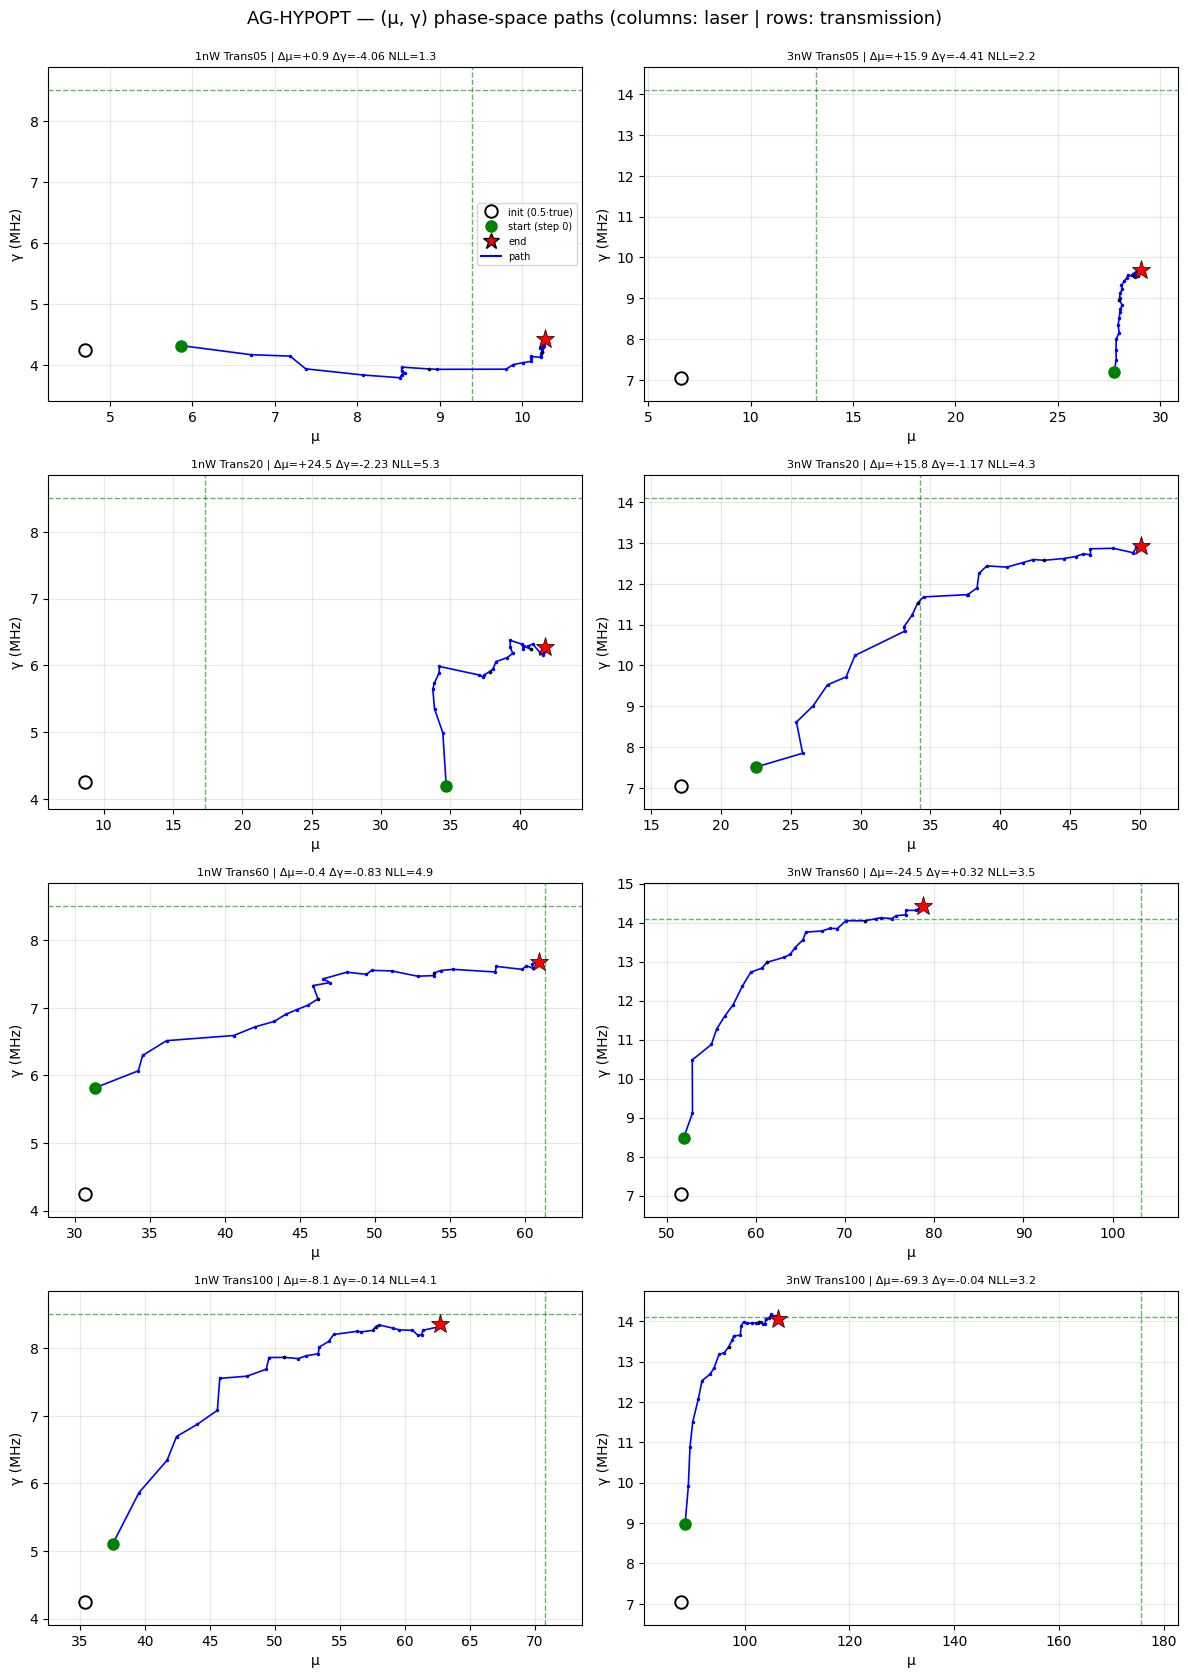

trial finished in 7.9 min
objective = 0.1167 ± 0.0824
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.28    +9.5 |     8.50    4.44   -47.8
1nW Trans20       17.32   41.84  +141.6 |     8.50    6.27   -26.2
1nW Trans60       61.37   60.96    -0.7 |     8.50    7.67    -9.8
1nW Trans100       70.82   62.71   -11.5 |     8.50    8.36    -1.6
3nW Trans05       13.20   29.07  +120.2 |    14.10    9.69   -31.2
3nW Trans20       34.28   50.09   +46.1 |    14.10   12.93    -8.3
3nW Trans60      103.20   78.69   -23.7 |    14.10   14.42    +2.2
3nW Trans100      175.71  106.42   -39.4 |    14.10   14.06    -0.3

weighted objective (T-graded, cap=1.0) = 0.1167 | diverged cells: 0
μ: RMSE 28.661 (rel 69.8%, bias -5.654) | γ: RMSE 2.320 (rel 22.7%, bias -1.569)


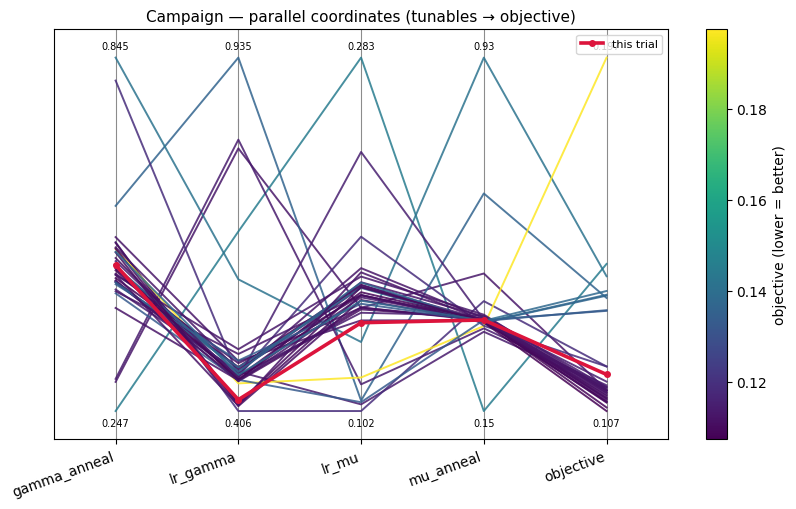

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 35 ran candidate 8 (ei=3.40; chosen over the top-ei candidate 4 because that sat at travel 0.291, beyond trial_02's already-bad 0.264). Config: `lr_mu=0.1475`, `mu_anneal=0.3510` (effective mu travel 0.122), `lr_gamma=0.4228`, `gamma_anneal=0.4942`. It completed in 7.9 min with objective **0.1167 +/- 0.0824** and **0 diverged cells**. Ranking: trial_21 0.1074 < ... < trial_07 0.1140 < trial_27 0.1149 < **trial_35 0.1167** < trial_06 = trial_11 0.1188 < ...

Aggregate accuracy: **mu rel-RMSE 69.8%** (RMSE 28.66, bias -5.65); **gamma rel-RMSE 22.7%** (RMSE 2.32, bias -1.57).

Per-cell relative errors:
- **mu:** 1nW T05 +9.5%, T20 +141.6%, T60 -0.7%, T100 -11.5% | 3nW T05 +120.2%, T20 +46.1%, T60 -23.7%, T100 -39.4%.
- **gamma:** 1nW T05 -47.8%, T20 -26.2%, T60 -9.8%, T100 -1.6% | 3nW T05 -31.2%, T20 -8.3%, T60 +2.2%, T100 -0.3%.

This sampled the lower edge of the band (travel 0.122) and, being divergence-free, it isolates the effect cleanly: the objective is 0.1167 — clearly worse than the 0.1074-0.1106 that travels 0.127-0.138 deliver, and close to trials 06/11's 0.1188 at the even-lower travel 0.082. So the fall-off below the optimum is genuine (not just a divergence artifact), and the productive band is narrow and centred at ~0.137. trial_21 (0.1074) remains the best.

**Summary:** Trial 35 (lr_mu=0.1475, mu_anneal=0.3510, lr_gamma=0.4228, gamma_anneal=0.4942): objective 0.1167 +/- 0.0824 with 0 diverged cells; a divergence-free sample at the lower edge of the band (travel 0.122) landed well off the optimum, so the band edge is genuinely worse and trial_21 (0.1074) stays best.
**Key insight:** Travel 0.122 gives 0.1167 - notably worse than 0.127-0.138 - confirming the optimum band is narrow and centred at ~0.137, and that the fall-off below it is a real schedule effect rather than a divergence artifact.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The mu axis is now characterised on both edges: travel 0.122 -> 0.1167 (clean), travel 0.194 -> 0.1149, travel 0.264 -> 0.1449, and the optimum 0.127-0.138 -> 0.1074-0.1106. The schedule search is exhausted; only the 1nW T05 divergence remains (structural). Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 35 (lr_mu=0.1475, mu_anneal=0.3510, lr_gamma=0.4228, gamma_anneal=0.4942): objective 0.1167 +/- 0.0824 with 0 diverged cells; a divergence-free sample at the lower edge of the band (travel 0.122) landed well off the optimum, so the band edge is genuinely worse and trial_21 (0.1074) stays best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Travel 0.122 gives 0.1167 - notably worse than 0.127-0.138 - confirming the optimum band is narrow and centred at ~0.137, and that the fall-off below it is a real schedule effect rather than a divergence artifact"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_35 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_36.ipynb. Open it and follow its cells from the top.
